<a href="https://colab.research.google.com/github/MelissaWachira/Accuracy-report/blob/main/Python_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Load Data and Summary
SPECIES CLASSIFICATION USING RANDOM FOREST, KNN AND K-MEANS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Palmer Penguins dataset directly from Seaborn
penguins = sns.load_dataset('penguins')

# View a summary of the data
penguins.describe(include='all')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,333
unique,3,3,NaN,NaN,NaN,NaN,2
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,Male
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


## 2. Exploratory Data Analysis (EDA)

Using a pairplot to visualize correlations between the penguin features (bill length, bill depth, flipper length, and body mass), grouped by species.

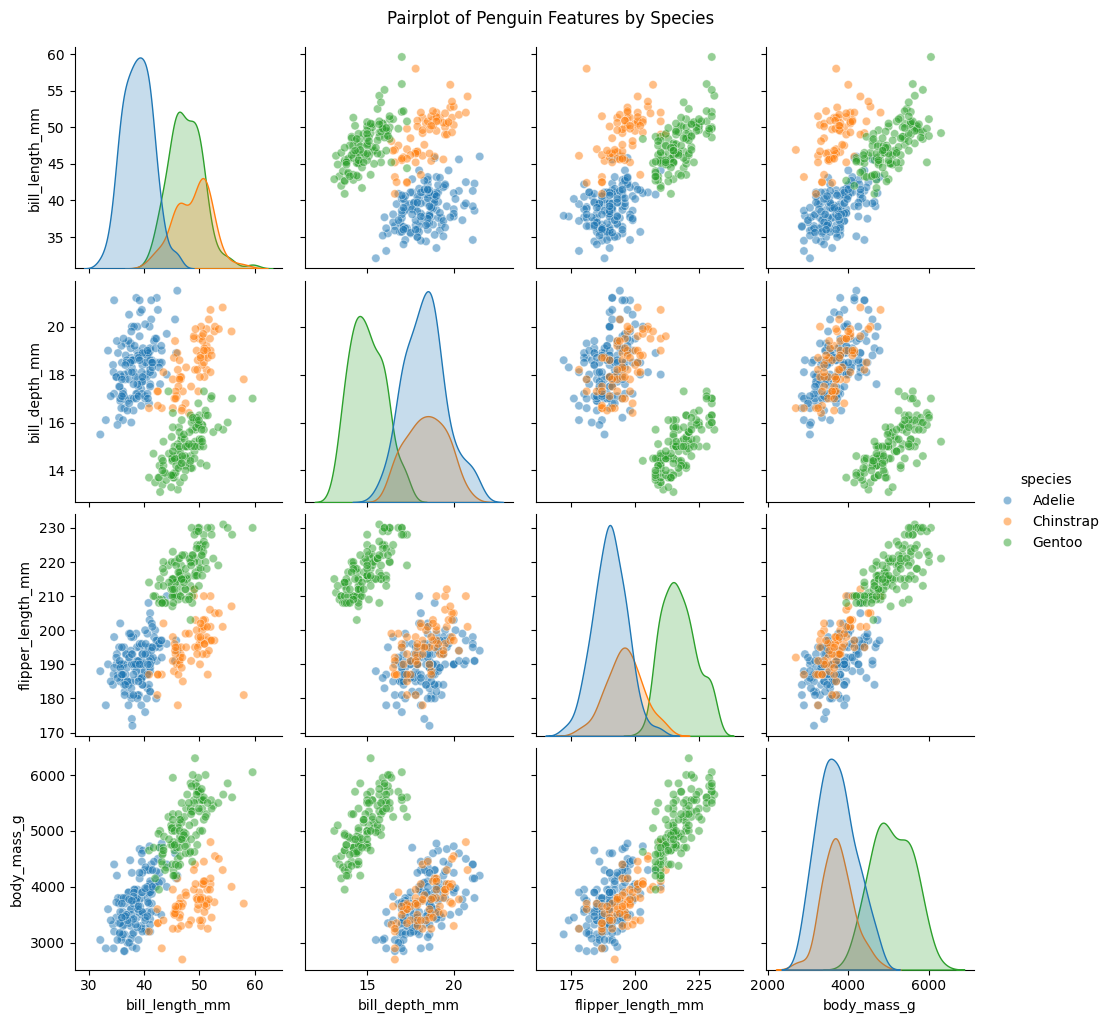

In [ ]:
# Remove rows with missing values for a cleaner plot
penguins_clean = penguins.dropna()

# Visualizing correlations and distributions
sns.pairplot(
    penguins_clean[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species']],
    hue='species',
    plot_kws={'alpha': 0.5}
)
plt.suptitle('Pairplot of Penguin Features by Species', y=1.02)
plt.show()

## 3. Data Preparation

To ensure accurate results, we first handle missing values and split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Clean data: Remove rows with NA values
penguins_clean = penguins.dropna()

# Select features and target
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_clean[features]
y = penguins_clean['species']

# Split data: 70% Training, 30% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 233
Testing samples:  100


## 4. Random Forest (Supervised Classification)

Random Forest builds multiple decision trees to classify species based on features like bill length and body mass.

              precision    recall  f1-score   support

      Adelie       0.98      0.93      0.95        44
   Chinstrap       0.86      0.95      0.90        20
      Gentoo       0.97      0.97      0.97        36

    accuracy                           0.95       100
   macro avg       0.94      0.95      0.94       100
weighted avg       0.95      0.95      0.95       100



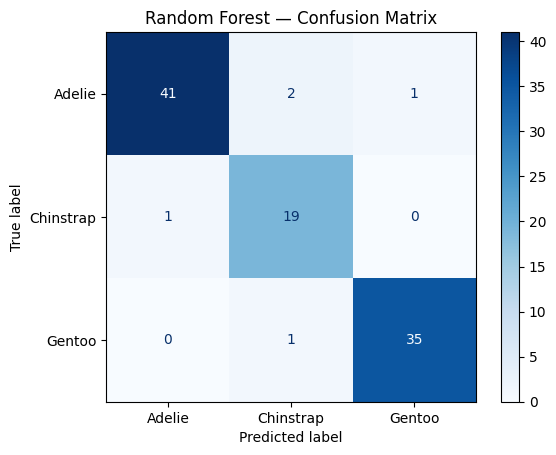

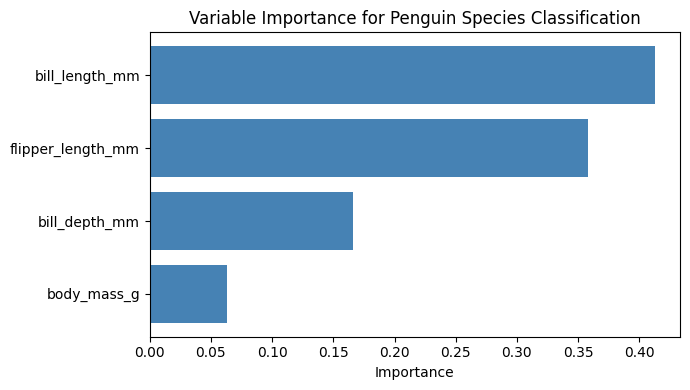

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=500, random_state=123)
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)

# Confusion Matrix
print(classification_report(y_test, rf_preds))
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.show()

# Variable Importance Plot
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance')

plt.figure(figsize=(7, 4))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Variable Importance for Penguin Species Classification')
plt.tight_layout()
plt.show()

## 5. K-Nearest Neighbors (KNN)



              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99        44
   Chinstrap       1.00      0.95      0.97        20
      Gentoo       1.00      1.00      1.00        36

    accuracy                           0.99       100
   macro avg       0.99      0.98      0.99       100
weighted avg       0.99      0.99      0.99       100



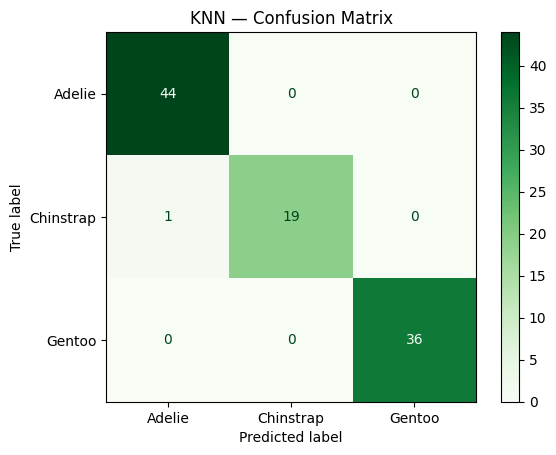

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


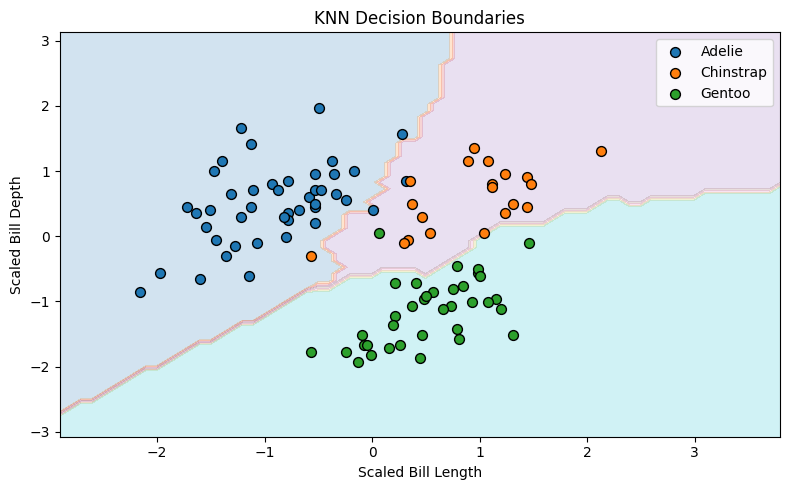

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Pre-process: Scale and Center numeric data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Run KNN (k=5)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)

# Evaluate
print(classification_report(y_test, knn_preds))
ConfusionMatrixDisplay.from_predictions(y_test, knn_preds, cmap='Greens')
plt.title('KNN — Confusion Matrix')
plt.show()

# KNN Decision Boundary Plot (using bill_length_mm vs bill_depth_mm)
train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=features)

x_min, x_max = train_scaled_df['bill_length_mm'].min() - 1, train_scaled_df['bill_length_mm'].max() + 1
y_min, y_max = train_scaled_df['bill_depth_mm'].min()  - 1, train_scaled_df['bill_depth_mm'].max()  + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Use only bill_length and bill_depth columns for the 2D boundary
knn_2d = KNeighborsClassifier(n_neighbors=5)
knn_2d.fit(train_scaled_df[['bill_length_mm', 'bill_depth_mm']], y_train.values)
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])

species_map = {s: i for i, s in enumerate(penguins_clean['species'].unique())}
Z_num = np.array([species_map[s] for s in Z]).reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z_num, alpha=0.2, cmap='tab10')
colors = {'Adelie': 'tab:blue', 'Chinstrap': 'tab:orange', 'Gentoo': 'tab:green'}
for sp in penguins_clean['species'].unique():
    mask = y_test.values == sp
    plt.scatter(test_scaled_df['bill_length_mm'].values[mask],
                test_scaled_df['bill_depth_mm'].values[mask],
                label=sp, color=colors[sp], edgecolors='k', s=50)
plt.xlabel('Scaled Bill Length')
plt.ylabel('Scaled Bill Depth')
plt.title('KNN Decision Boundaries')
plt.legend()
plt.tight_layout()
plt.show()

## 6. K-Means (Unsupervised Clustering)

Unlike the models above, K-Means does not use the species labels. It attempts to find three natural clusters in the data based purely on physical measurements.

species  Adelie  Chinstrap  Gentoo
cluster                           
0             0          0     119
1            22         63       0
2           124          5       0


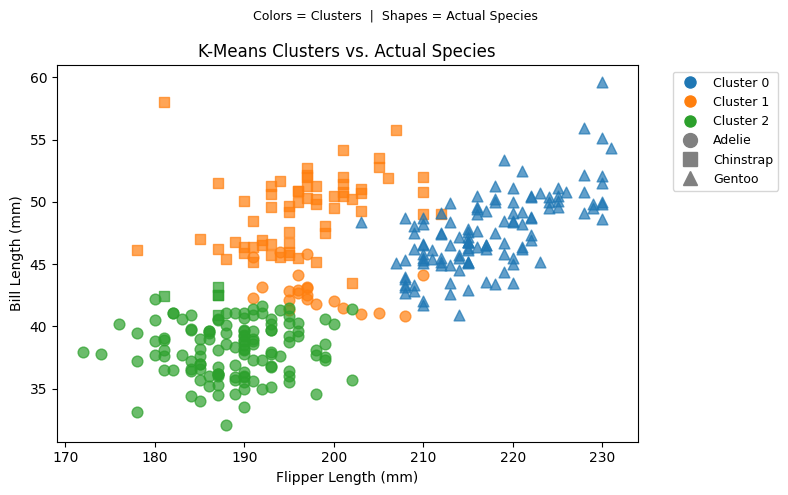

In [ ]:
from sklearn.cluster import KMeans

# Select numeric columns and scale
penguin_features = scaler.fit_transform(penguins_clean[features])

# Run K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, n_init=25, random_state=123)
kmeans.fit(penguin_features)

penguins_clean = penguins_clean.copy()
penguins_clean['cluster'] = kmeans.labels_.astype(str)

# Cluster vs actual species cross-tabulation
print(pd.crosstab(penguins_clean['cluster'], penguins_clean['species']))

# Visualize Clusters vs Species
markers = {'Adelie': 'o', 'Chinstrap': 's', 'Gentoo': '^'}
palette = {'0': 'tab:blue', '1': 'tab:orange', '2': 'tab:green'}

plt.figure(figsize=(8, 5))
for species, marker in markers.items():
    subset = penguins_clean[penguins_clean['species'] == species]
    for cluster, color in palette.items():
        sub = subset[subset['cluster'] == cluster]
        plt.scatter(sub['flipper_length_mm'], sub['bill_length_mm'],
                    color=color, marker=marker, alpha=0.7, s=60,
                    label=f'Cluster {cluster} / {species}' if not plt.gca().get_legend_handles_labels()[1] else '_')

# Clean legend
from matplotlib.lines import Line2D
legend_clusters = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=10, label=f'Cluster {k}') for k, c in palette.items()]
legend_species  = [Line2D([0],[0], marker=m, color='grey', markersize=10, linestyle='None', label=s) for s, m in markers.items()]
plt.legend(handles=legend_clusters + legend_species, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.xlabel('Flipper Length (mm)')
plt.ylabel('Bill Length (mm)')
plt.title('K-Means Clusters vs. Actual Species')
plt.suptitle('Colors = Clusters  |  Shapes = Actual Species', fontsize=9, y=0.98)
plt.tight_layout()
plt.show()